In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from scipy.stats import zscore

## Phase 1: Data Exploration

part1:

In [4]:
df = pd.read_csv('Metro_Interstate_Traffic_Volume.csv')
df.shape

(48204, 9)

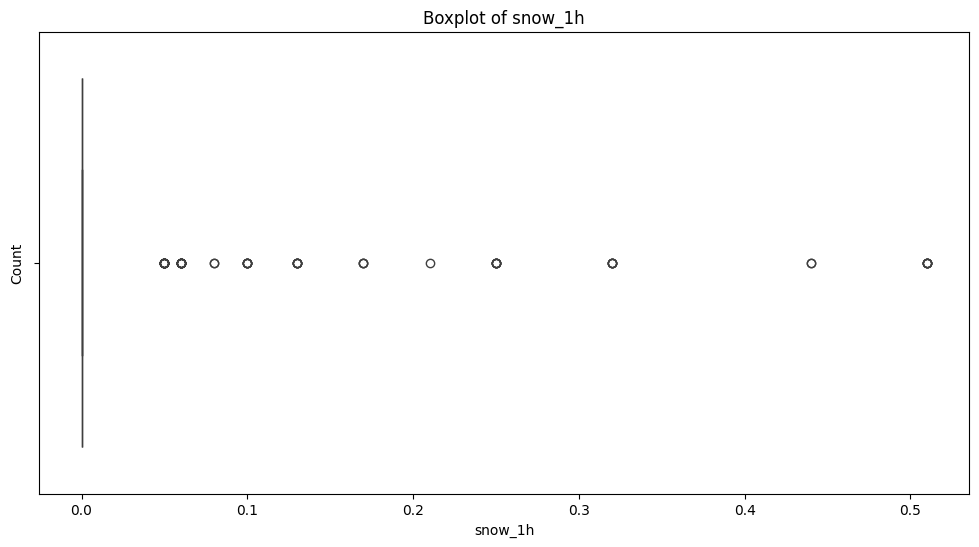

In [5]:

feature = 'snow_1h'
plt.figure(figsize=(12, 6))
sns.boxplot(x=df[feature])
plt.title(f'Boxplot of {feature}')
plt.xlabel(feature)
plt.ylabel('Count')
plt.show()

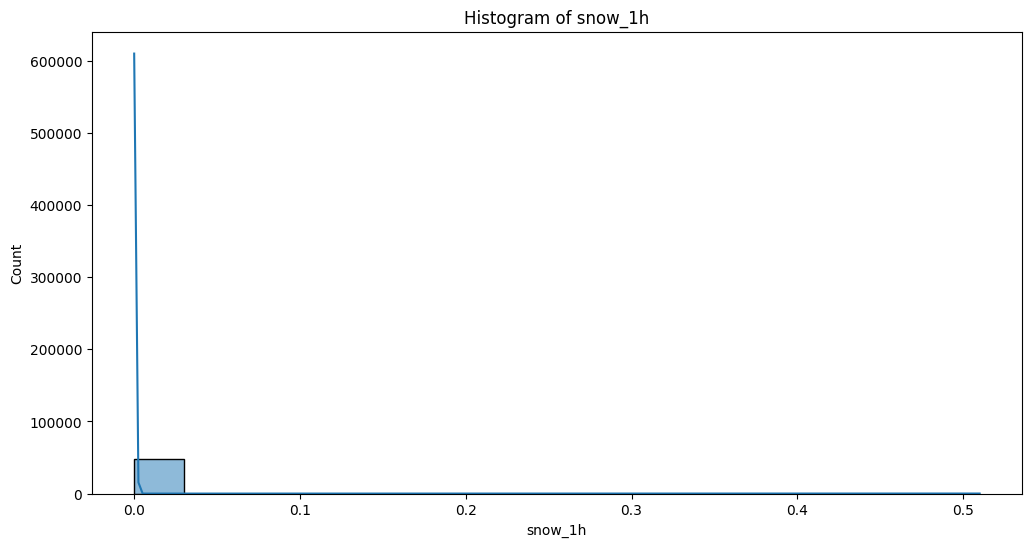

In [6]:
plt.figure(figsize=(12, 6))
sns.histplot(df[feature], kde=True)
plt.title(f'Histogram of {feature}')
plt.show()

part2:

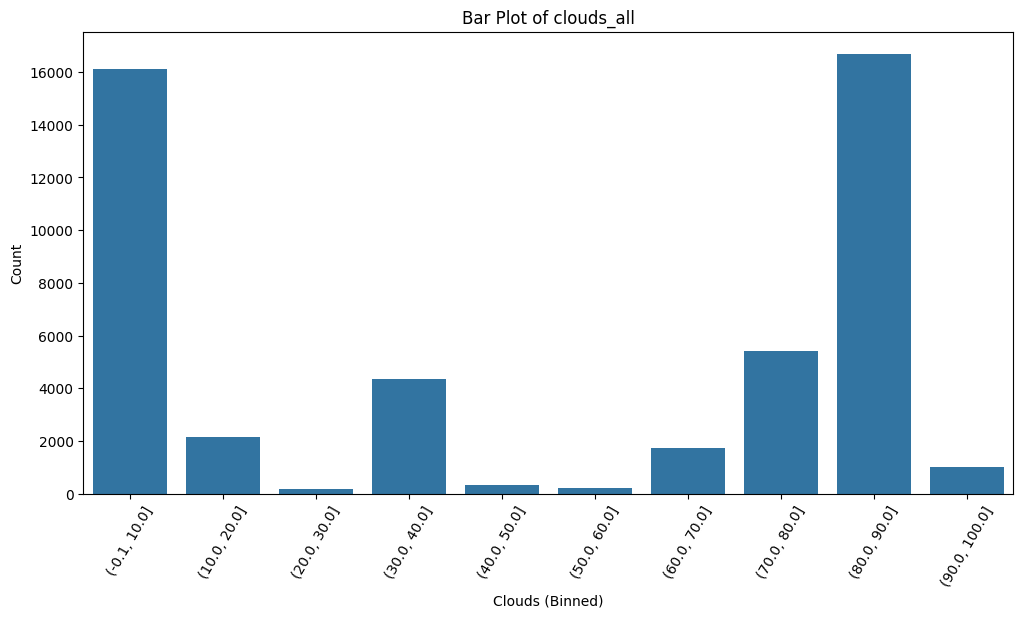

In [7]:
df['clouds_all_bins'] = pd.cut(df['clouds_all'], bins=10)

plt.figure(figsize=(12, 6))
sns.countplot(x=df['clouds_all_bins'])

plt.title('Bar Plot of clouds_all')
plt.xticks(rotation=60)
plt.xlabel('Clouds (Binned)')
plt.ylabel('Count')
plt.show()

## Phase 2: Data Preprocessing


In [8]:
print(df.isnull().sum())


holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
clouds_all_bins            0
dtype: int64


In [9]:
df_filtered = df[df['holiday'] != None]
df_filtered

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,clouds_all_bins
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,"(30.0, 40.0]"
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,"(70.0, 80.0]"
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,"(80.0, 90.0]"
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,"(80.0, 90.0]"
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,"(70.0, 80.0]"
...,...,...,...,...,...,...,...,...,...,...
48199,NaN,283.45,0.0,0.0,75,Clouds,broken clouds,2018-09-30 19:00:00,3543,"(70.0, 80.0]"
48200,NaN,282.76,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 20:00:00,2781,"(80.0, 90.0]"
48201,NaN,282.73,0.0,0.0,90,Thunderstorm,proximity thunderstorm,2018-09-30 21:00:00,2159,"(80.0, 90.0]"
48202,NaN,282.09,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 22:00:00,1450,"(80.0, 90.0]"


In [10]:
df = df.drop(columns=['holiday'])
df.head()

,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,clouds_all_bins
0,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,"(30.0, 40.0]"
1,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,"(70.0, 80.0]"
2,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,"(80.0, 90.0]"
3,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,"(80.0, 90.0]"
4,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,"(70.0, 80.0]"


In [11]:
scaler = StandardScaler()
features = ['temp', 'rain_1h', 'snow_1h', 'clouds_all']
df[features] = scaler.fit_transform(df[features])
df.iloc[0:50]

,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,clouds_all_bins
0,0.530370,-0.007463,-0.027228,-0.239963,Clouds,scattered clouds,2012-10-02 09:00:00,5545,"(30.0, 40.0]"
1,0.611341,-0.007463,-0.027228,0.657120,Clouds,broken clouds,2012-10-02 10:00:00,4516,"(70.0, 80.0]"
2,0.627836,-0.007463,-0.027228,1.041584,Clouds,overcast clouds,2012-10-02 11:00:00,4767,"(80.0, 90.0]"
3,0.669071,-0.007463,-0.027228,1.041584,Clouds,overcast clouds,2012-10-02 12:00:00,5026,"(80.0, 90.0]"
4,0.744794,-0.007463,-0.027228,0.657120,Clouds,broken clouds,2012-10-02 13:00:00,4918,"(70.0, 80.0]"
5,0.788278,-0.007463,-0.027228,-1.239569,Clear,sky is clear,2012-10-02 14:00:00,5181,"(-0.1, 10.0]"
6,0.896989,-0.007463,-0.027228,-1.239569,Clear,sky is clear,2012-10-02 15:00:00,5584,"(-0.1, 10.0]"
7,0.948721,-0.007463,-0.027228,-1.239569,Clear,sky is clear,2012-10-02 16:00:00,6015,"(-0.1, 10.0]"
8,0.969714,-0.007463,-0.027228,-0.752582,Clouds,few clouds,2012-10-02 17:00:00,5791,"(10.0, 20.0]"
9,0.891741,-0.007463,-0.027228,-0.752582,Clouds,few clouds,2012-10-02 18:00:00,4770,"(10.0, 20.0]"


In [12]:
encoder = OneHotEncoder(sparse=False)
categorical_features = ['weather_main', 'weather_description']
encoded_features = encoder.fit_transform(df[categorical_features])
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_features))
df = df.drop(categorical_features, axis=1)
df = pd.concat([df, encoded_df], axis=1)

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [13]:
df.iloc[0:50]

,temp,rain_1h,snow_1h,clouds_all,date_time,traffic_volume,clouds_all_bins,weather_main_Clear,weather_main_Clouds,weather_main_Drizzle,...,weather_description_sleet,weather_description_smoke,weather_description_snow,weather_description_thunderstorm,weather_description_thunderstorm with drizzle,weather_description_thunderstorm with heavy rain,weather_description_thunderstorm with light drizzle,weather_description_thunderstorm with light rain,weather_description_thunderstorm with rain,weather_description_very heavy rain
0,0.530370,-0.007463,-0.027228,-0.239963,2012-10-02 09:00:00,5545,"(30.0, 40.0]",0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.611341,-0.007463,-0.027228,0.657120,2012-10-02 10:00:00,4516,"(70.0, 80.0]",0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.627836,-0.007463,-0.027228,1.041584,2012-10-02 11:00:00,4767,"(80.0, 90.0]",0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.669071,-0.007463,-0.027228,1.041584,2012-10-02 12:00:00,5026,"(80.0, 90.0]",0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.744794,-0.007463,-0.027228,0.657120,2012-10-02 13:00:00,4918,"(70.0, 80.0]",0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.788278,-0.007463,-0.027228,-1.239569,2012-10-02 14:00:00,5181,"(-0.1, 10.0]",1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.896989,-0.007463,-0.027228,-1.239569,2012-10-02 15:00:00,5584,"(-0.1, 10.0]",1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.948721,-0.007463,-0.027228,-1.239569,2012-10-02 16:00:00,6015,"(-0.1, 10.0]",1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.969714,-0.007463,-0.027228,-0.752582,2012-10-02 17:00:00,5791,"(10.0, 20.0]",0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.891741,-0.007463,-0.027228,-0.752582,2012-10-02 18:00:00,4770,"(10.0, 20.0]",0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
def remove_outliers_iqr(df, columns):
    df_cleaned = df.copy()
    for column in columns:

        Q1 = df_cleaned[column].quantile(0.25)
        Q3 = df_cleaned[column].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.2 * IQR
        upper_bound = Q3 + 1.2 * IQR

        df_cleaned = df_cleaned[(df_cleaned[column] >= lower_bound) & (df_cleaned[column] <= upper_bound)]

    return df_cleaned

columns_to_check = ['temp', 'clouds_all', 'traffic_volume']


df_cleaned_iqr = remove_outliers_iqr(df, columns_to_check)

print("Data after IQR outlier removal:")
print(df_cleaned_iqr.shape)
print('number of rows removed=', df.shape[0] - df_cleaned_iqr.shape[0])

Data after IQR outlier removal:
(48029, 56)
number of rows removed= 175


In [15]:
df=df_cleaned_iqr

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder




df['date_time'] = pd.to_datetime(df['date_time'])
df['year'] = df['date_time'].dt.year
df['month'] = df['date_time'].dt.month
df['day'] = df['date_time'].dt.day
df['hour'] = df['date_time'].dt.hour
df['weekday'] = df['date_time'].dt.weekday


df = df.drop(columns=['date_time'])


features = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'year', 'month', 'day', 'hour', 'weekday']
X = df[features]
y = df['traffic_volume']

scaler = StandardScaler()
X[features] = scaler.fit_transform(X[features])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)




Training set shape: (38423, 9)
Testing set shape: (9606, 9)


<ipython-input-16-d91419d22b79>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[features] = scaler.fit_transform(X[features])


## Phase 3: Model Development

In [17]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
results = []

k_values = [1,3,5,10,50,100]
for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)


    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'k': k,
        'MAE': mae,
        'MSE': mse,
        'R-squared': r2
    })

results_df = pd.DataFrame(results)
print("KNN Model Evaluation Results:")
results_df




KNN Model Evaluation Results:


,k,MAE,MSE,R-squared
0,1,522.992088,7.908988e+05,0.795603
1,3,539.914220,6.765054e+05,0.825166
2,5,571.754778,6.955082e+05,0.820255
3,10,601.007266,6.929336e+05,0.820921
4,50,748.590754,9.564676e+05,0.752814
5,100,841.951543,1.154177e+06,0.701719


In [18]:

print("Best k value based on R-squared:")
best_k = results_df.loc[results_df['R-squared'].idxmax()]
print(best_k)


Best k value based on R-squared:
k                 3.000000
MAE             539.914220
MSE          676505.412798
R-squared         0.825166
Name: 1, dtype: float64


## Phase 4: Model Fine-Tuning

In [30]:
#use grid search
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import KFold
knn = KNeighborsRegressor()


param_grid = {
    'n_neighbors': [3, 5]
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}


kfold = KFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(estimator=knn, param_grid=param_grid, cv=kfold, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)




In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

best_params = grid_search.best_params_
y_pred = grid_search.best_estimator_.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Best Hyperparameters:", best_params)
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R²): {r2}")



Best Hyperparameters: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}
Mean Absolute Error (MAE): 424.40679670443797
Mean Squared Error (MSE): 488870.5863252371
R-squared (R²): 0.8736580530870146


### Phase 5: Conclusion

In [32]:
results = grid_search.cv_results_
print(results)

{'mean_fit_time': array([0.1204432 , 0.08166642, 0.11043806, 0.08163505, 0.10013938,
       0.07978516, 0.10770092, 0.11978874]), 'std_fit_time': array([0.02668586, 0.00354723, 0.034372  , 0.0014317 , 0.04183193,
       0.00263595, 0.03817193, 0.04736461]), 'mean_score_time': array([3.18060918, 2.14230566, 3.52092347, 2.44916139, 3.81749821,
       3.02339988, 4.36917472, 4.23234897]), 'std_score_time': array([0.65345721, 0.48214987, 0.61466034, 0.53160263, 1.20114121,
       0.81703015, 1.5860419 , 1.31447611]), 'param_metric': masked_array(data=['euclidean', 'euclidean', 'euclidean', 'euclidean',
                   'manhattan', 'manhattan', 'manhattan', 'manhattan'],
             mask=[False, False, False, False, False, False, False, False],
       fill_value='?',
            dtype=object), 'param_n_neighbors': masked_array(data=[3, 3, 5, 5, 3, 3, 5, 5],
             mask=[False, False, False, False, False, False, False, False],
       fill_value='?',
            dtype=object), 'para

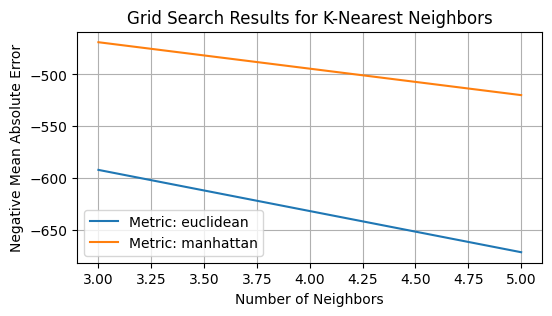

In [35]:
import matplotlib.pyplot as plt


plt.figure(figsize=(6, 3))
mean_test_scores = np.array(results['mean_test_score']).reshape(len(param_grid['n_neighbors']), len(param_grid['weights']), len(param_grid['metric']))

for metric in param_grid['metric']:
    plt.plot(param_grid['n_neighbors'], mean_test_scores[:, :, param_grid['metric'].index(metric)].mean(axis=1),
             label=f'Metric: {metric}')

plt.xlabel('Number of Neighbors')
plt.ylabel('Negative Mean Absolute Error')
plt.title('Grid Search Results for K-Nearest Neighbors')
plt.legend()
plt.grid(True)
plt.show()